In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import data_access_module as da
import data_processor as dp
import analyser_module as am
from data_processor import aggregate_hour
import visualizer_module as viz

OCT23 = da.get_okte_data_simple("DAM", datetime(2023, 10, 1), datetime(2023, 10, 31))
OCT23 = dp.prep_okte_data(OCT23)
OCT24 = da.get_okte_data_simple("DAM", datetime(2024, 10, 1), datetime(2024, 10, 31))
OCT24 = dp.prep_okte_data(OCT24)
OCT25 = da.get_okte_data_simple("DAM", datetime(2025, 10, 1), datetime(2025, 10, 31))
OCT25 = dp.prep_okte_data(OCT25)
OCT25H = dp.aggregate_hour(OCT25, "price")
OCT25H = dp.calculate_price_diff(OCT25H)


NOV23 = da.get_okte_data_simple("DAM", datetime(2023, 11, 1), datetime(2023, 11, 30))
NOV23 = dp.prep_okte_data(NOV23)
NOV24 = da.get_okte_data_simple("DAM", datetime(2024, 11, 1), datetime(2024, 11, 30))
NOV24 = dp.prep_okte_data(NOV24)
NOV25 = da.get_okte_data_simple("DAM", datetime(2025, 11, 1), datetime(2025, 11, 30))
NOV25 = dp.prep_okte_data(NOV25)
NOV25H = dp.aggregate_hour(NOV25, "price")
NOV25H = dp.calculate_price_diff(NOV25H)

DEC23 = da.get_okte_data_simple("DAM", datetime(2023, 12, 1), datetime(2023, 12, 31))
DEC23 = dp.prep_okte_data(DEC23)
DEC24 = da.get_okte_data_simple("DAM", datetime(2024, 12, 1), datetime(2024, 12, 31))
DEC24 = dp.prep_okte_data(DEC24)
DEC25 = da.get_okte_data_simple("DAM", datetime(2025, 12, 1), datetime(2025, 12, 31))
DEC25 = dp.prep_okte_data(DEC25)
DEC25H = dp.aggregate_hour(DEC25, "price")
DEC25H = dp.calculate_price_diff(DEC25H)


OND2023 = dp.combine_datasets(OCT23,NOV23)
OND2023 = dp.combine_datasets(OND2023,DEC23)
OND2023 = dp.remove_nonstandard_days(OND2023)

OND2024 = dp.combine_datasets(OCT24,NOV24)
OND2024 = dp.combine_datasets(OND2024,DEC24)
OND2024 = dp.remove_nonstandard_days(OND2024)

OND2025 = dp.combine_datasets(OCT25,NOV25)
OND2025 = dp.combine_datasets(OND2025,DEC25)

OND2025H = dp.combine_datasets(OCT25H,NOV25H)
OND2025H = dp.combine_datasets(OND2025H,DEC25H)

October2023stats = am.price_diff_summary_statistics(OCT23)
October2024stats = am.price_diff_summary_statistics(OCT24)
October2025Hstats = am.price_diff_summary_statistics(OCT25H)
October2025QHstats = am.price_diff_summary_statistics(OCT25)

summary_dfO = pd.DataFrame({
    "Október 2023": October2023stats,
    "Október 2024": October2024stats,
    "Október 2025H": October2025Hstats,
    "Október 2025QH": October2025QHstats
}).round(2)

# November price difference statistics
November2023stats = am.price_diff_summary_statistics(NOV23)
November2024stats = am.price_diff_summary_statistics(NOV24)
November2025Hstats = am.price_diff_summary_statistics(NOV25H)
November2025QHstats = am.price_diff_summary_statistics(NOV25)

summary_dfN = pd.DataFrame({
    "November 2023": November2023stats,
    "November 2024": November2024stats,
    "November 2025H": November2025Hstats,
    "November 2025QH": November2025QHstats
}).round(2)

# December price difference statistics
December2023stats = am.price_diff_summary_statistics(DEC23)
December2024stats = am.price_diff_summary_statistics(DEC24)
December2025Hstats = am.price_diff_summary_statistics(DEC25H)
December2025QHstats = am.price_diff_summary_statistics(DEC25)

summary_dfD = pd.DataFrame({
    "December 2023": December2023stats,
    "December 2024": December2024stats,
    "December 2025H": December2025Hstats,
    "December 2025QH": December2025QHstats
}).round(2)

summary_dfO

,Október 2023,Október 2024,Október 2025H,Október 2025QH
mean price diff,-0.01,0.16,-0.03,-0.02
std price diff,23.60,24.57,24.97,20.65
mean abs price diff,16.64,16.89,14.93,13.73
Max abs price diff,117.68,106.03,180.23,134.88
q99 abs price diff,82.49,79.83,94.97,72.37
q95 abs price diff,46.19,54.02,46.86,44.40
Skewness price diff,-0.40,0.17,-0.33,0.22
Kurtosis price diff,6.42,5.58,17.02,8.19


In [4]:
summary_dfN

,November 2023,November 2024,November 2025H,November 2025QH
mean price diff,0.07,-0.01,0.00,-0.01
std price diff,15.69,34.78,18.29,16.62
mean abs price diff,10.37,18.39,11.88,10.32
Max abs price diff,102.30,319.91,103.20,141.11
q99 abs price diff,56.13,158.32,71.14,63.71
q95 abs price diff,32.78,57.19,39.01,33.51
Skewness price diff,0.15,-0.18,0.28,-0.11
Kurtosis price diff,9.36,25.91,8.62,12.23


In [5]:
summary_dfD

,December 2023,December 2024,December 2025H,December 2025QH
mean price diff,-0.12,0.06,-0.01,-0.01
std price diff,10.72,36.04,11.52,9.75
mean abs price diff,7.44,18.17,7.55,6.71
Max abs price diff,54.57,390.98,66.42,84.03
q99 abs price diff,33.54,168.71,46.14,31.34
q95 abs price diff,22.06,56.54,24.46,20.71
Skewness price diff,0.88,0.71,0.73,-0.02
Kurtosis price diff,6.44,37.95,8.83,8.42


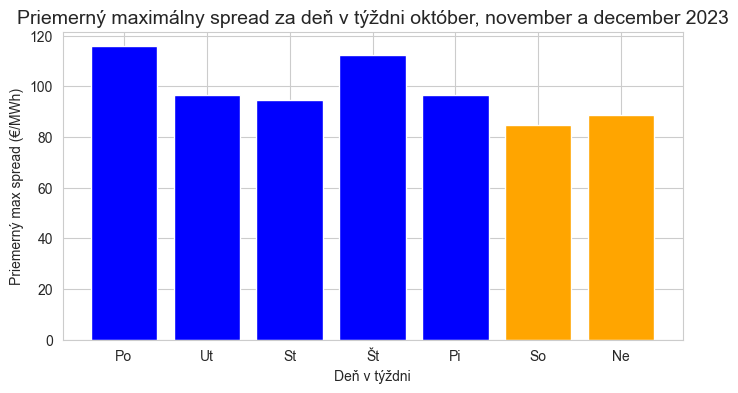

In [6]:
weekdayspread = am.avg_daily_max_spread_by_weekday(OND2023)
fig, ax = viz.plot_weekday_bar(weekdayspread, "Priemerný maximálny spread za deň v týždni október, november a december 2023","Priemerný max spread (€/MWh)")
display(fig)

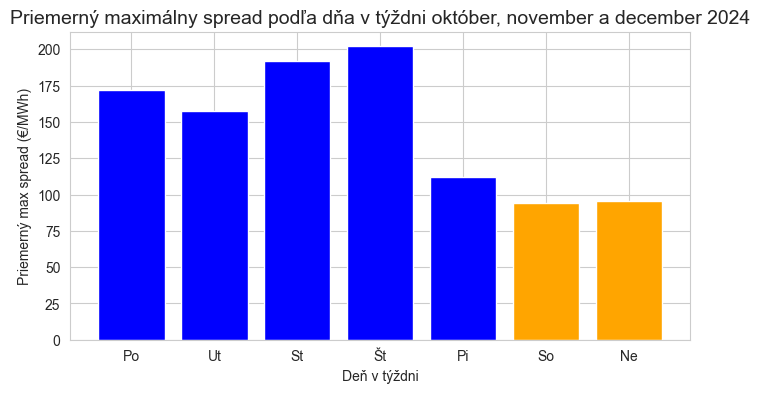

In [7]:
weekdayspread = am.avg_daily_max_spread_by_weekday(OND2024)
fig, ax = viz.plot_weekday_bar(weekdayspread, "Priemerný maximálny spread podľa dňa v týždni október, november a december 2024","Priemerný max spread (€/MWh)")
display(fig)

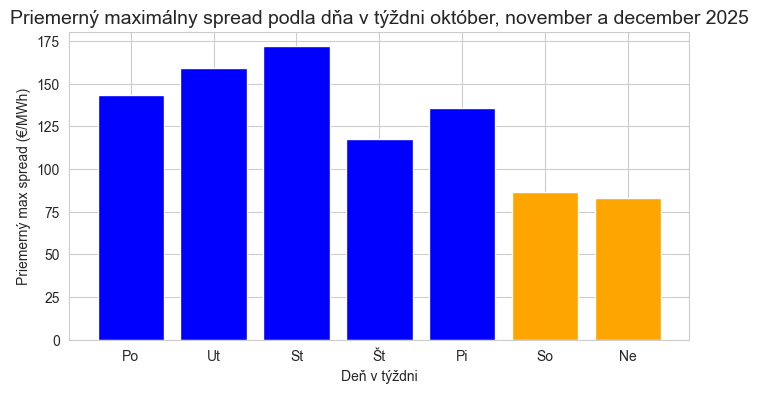

In [8]:
weekdayspread = am.avg_daily_max_spread_by_weekday(OND2025)
fig, ax = viz.plot_weekday_bar(weekdayspread, "Priemerný maximálny spread podla dňa v týždni október, november a december 2025","Priemerný max spread (€/MWh)")
display(fig)